In [70]:
import pandas as pd
from glob import glob

# retina resolution for plots
%config InlineBackend.figure_format = 'retina'

In [2]:
# all=[]
# for f in glob('/Users/sala6791/Library/CloudStorage/OneDrive-UCB-O365/Documents/EAGLE/datasets/BBS/50-StopData/*.csv'):
#     all.append(pd.read_csv(f))
# pd.concat(all).to_parquet('../datasets/BBS/50-StopData.parquet', index=False)

In [3]:
# select first stop per route

In [77]:
all = pd.read_parquet('../datasets/BBS/50-StopData.parquet')
all['RouteID']=all['CountryNum'].astype(str).str.zfill(2) + '_' + all['StateNum'].astype(str).str.zfill(2) + '_' + all['Route'].astype(str).str.zfill(3)


In [78]:
stop1 = all[['RouteDataID', 'CountryNum', 'StateNum', 'Route', 'RouteID', 'RPID', 'Year', 'AOU','Stop1']]

In [79]:
stop1.to_parquet('../datasets/BBS/50-StopData_Stop1.parquet', index=False)

In [80]:
route_table = pd.read_csv('../datasets/BBS/Routes.csv', encoding='latin1')
route_table['RouteID']=route_table['CountryNum'].astype(str).str.zfill(2) + '_' + route_table['StateNum'].astype(str).str.zfill(2) + '_' + route_table['Route'].astype(str).str.zfill(3)
route_table.to_parquet('../datasets/BBS/Routes_withID.parquet', index=False)
route_table.head(1)

,CountryNum,StateNum,Route,RouteName,Active,Latitude,Longitude,Stratum,BCR,RouteTypeID,RouteTypeDetailID,RouteID
0,840,2,1,ST FLORIAN,1,34.873263,-87.604225,14,27,1,1,840_02_001


In [82]:
# long to wide with AOU as columns
stop1_wide = stop1.pivot_table(index=['RouteID', 'RouteDataID', 'Year'], columns='AOU', values='Stop1').fillna(0).reset_index()

In [83]:
stop1_wide.head()

AOU,RouteID,RouteDataID,Year,10,11,12,20,30,40,50,...,7680,8110,10210,16600,19510,20630,21930,22860,51830,52021
0,124_04_001,6167164,2000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,124_04_001,6248812,2005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,124_04_001,6297584,2006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,124_04_001,6297586,2007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,124_04_001,6358333,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
taxonomy = pd.read_csv('../datasets/BBS/SpeciesList.csv', encoding='latin1', index_col='AOU')
# filter out species with 'unid' indicating not identified to species
taxonomy['include'] = ~taxonomy['English_Common_Name'].str.contains('unid', case=False, na=True)
extra_cols=3
cols = list(stop1_wide.columns[:extra_cols]) + list(stop1_wide.columns[extra_cols:].map(taxonomy['English_Common_Name'].to_dict()))
wide_w_names = stop1_wide.copy()
wide_w_names.columns = cols

# remove non-species columns
col_mask = [True]*extra_cols + list(taxonomy['include'].to_dict().get(aou, False) for aou in stop1_wide.columns[extra_cols:])
wide_w_names = wide_w_names.loc[:, col_mask]
wide_w_names.shape

(86503, 673)

In [120]:
wide_w_names_and_coords = wide_w_names.merge(route_table[['RouteID', 'Latitude', 'Longitude']], on='RouteID', how='left')

In [121]:
wide_w_names_and_coords.to_parquet('../datasets/BBS/50-StopData_Stop1_wide_commonName.parquet', index=False)

In [142]:
richness = wide_w_names_and_coords.drop(columns=['RouteDataID', 'Year', 'Latitude', 'Longitude']).groupby('RouteID').max().clip(0,1).sum(1)
richness=richness.to_frame('species_richness').merge(route_table[['RouteID', 'Latitude', 'Longitude']], on='RouteID', how='left')
richness

/var/folders/_1/clc139q504qfy1s2zl7qf9h00000gr/T/ipykernel_94441/718994153.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  richness = wide_w_names_and_coords.drop(columns=['RouteDataID', 'Year', 'Latitude', 'Longitude']).groupby('RouteID').max().clip(0,1).sum(1)


,RouteID,species_richness,Latitude,Longitude
0,124_04_001,22.0,49.932220,-110.844520
1,124_04_002,37.0,49.873240,-111.410200
2,124_04_003,32.0,49.089950,-112.396990
3,124_04_004,33.0,49.815090,-113.569820
4,124_04_006,19.0,50.746680,-110.258690
...,...,...,...,...
5118,840_92_350,14.0,44.326570,-104.224140
5119,840_92_424,5.0,41.702569,-108.429820
5120,840_92_524,3.0,41.702569,-108.429820
5121,840_92_901,21.0,44.767893,-110.455358


Text(0.5, 1.0, 'Species richness of BBS routes')

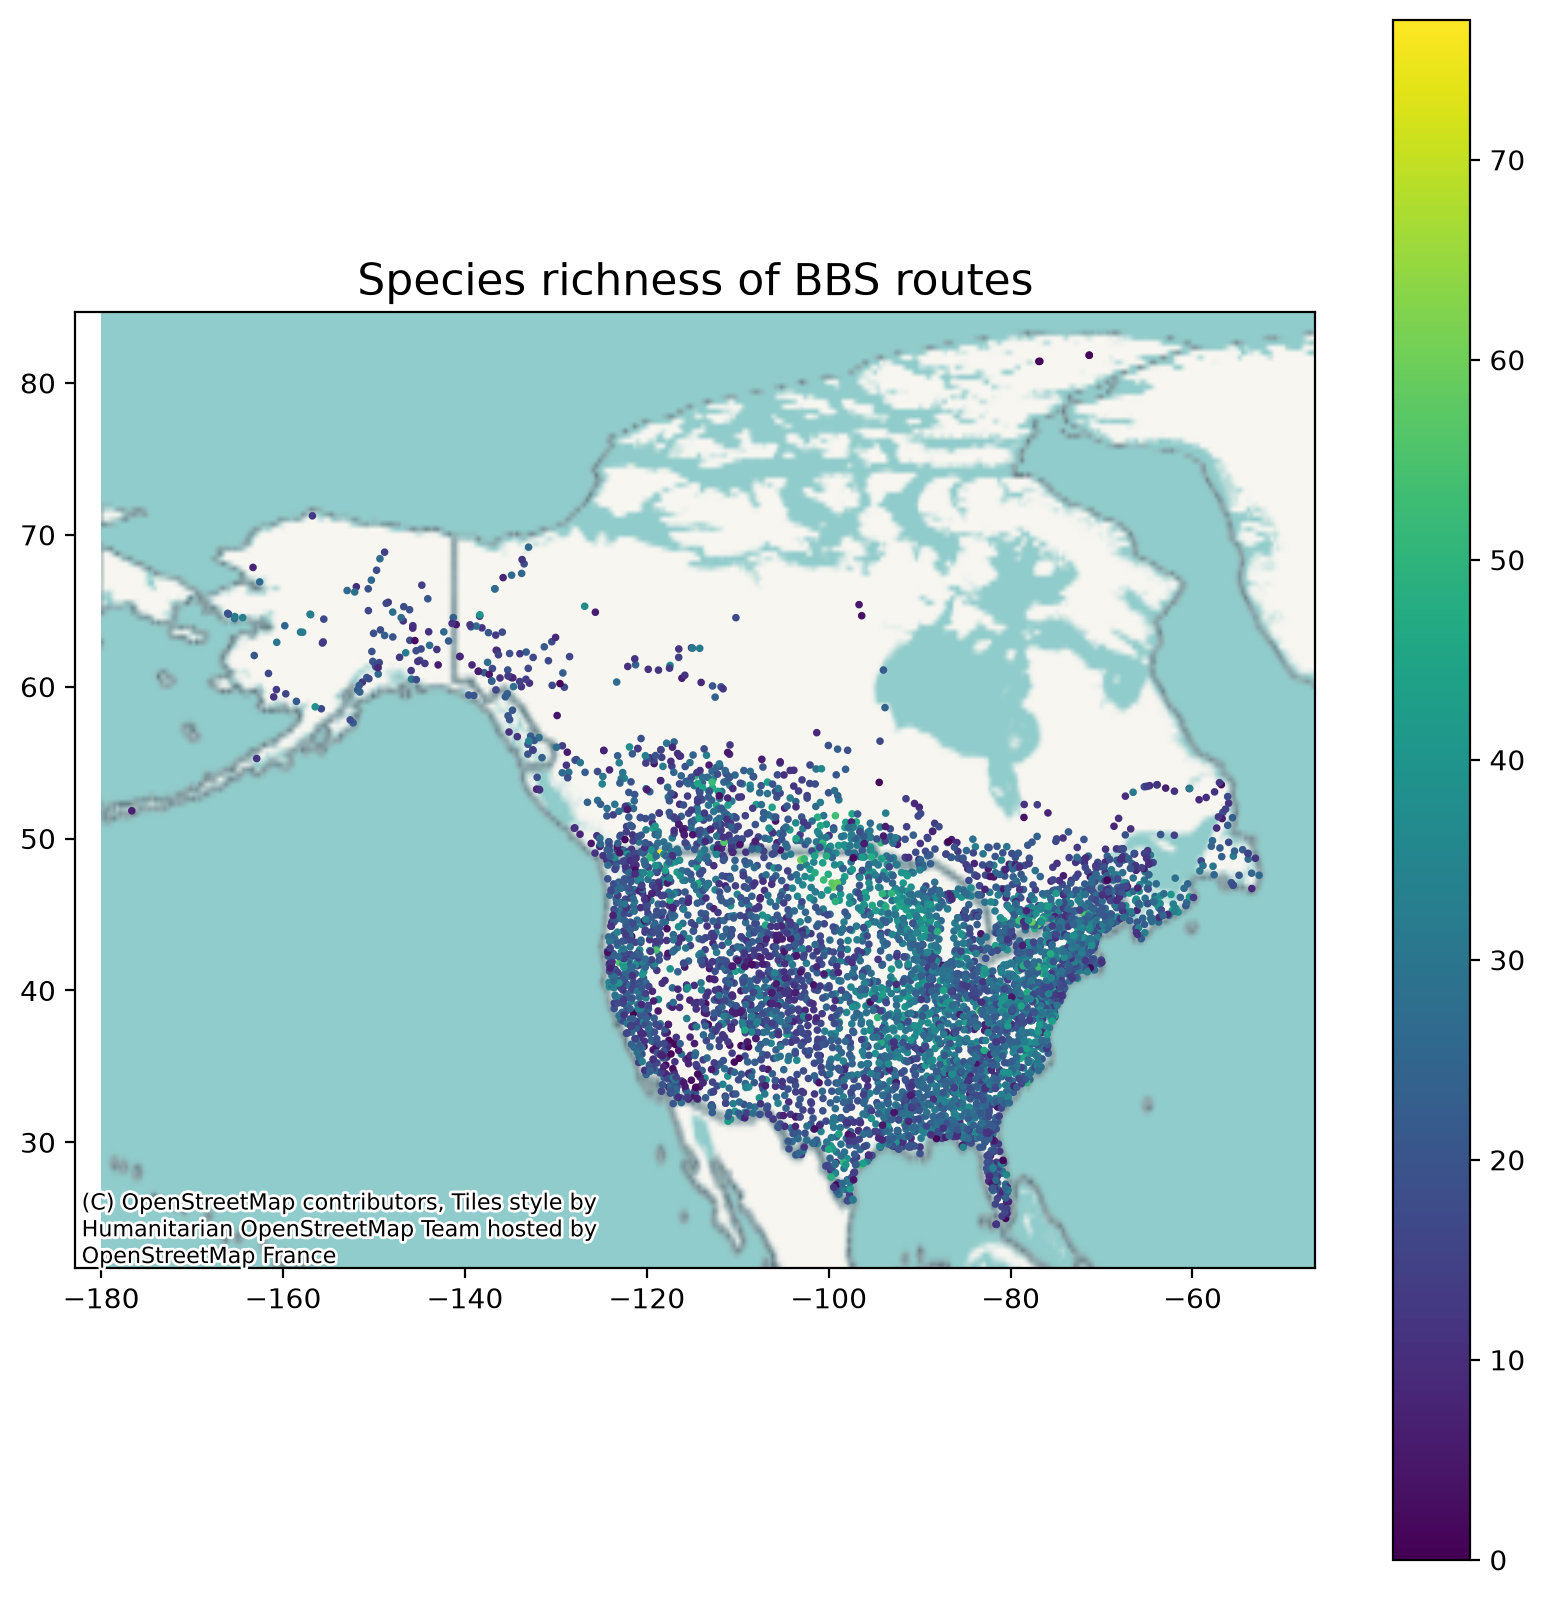

In [148]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
gdf = gpd.GeoDataFrame(richness, geometry=gpd.points_from_xy(richness.Longitude, richness.Latitude), crs='EPSG:4326')
gdf.plot(column='species_richness', cmap='viridis', legend=True, figsize=(10,10),s=3)
ctx.add_basemap(plt.gca(), crs=gdf.crs.to_string())
plt.title('Species richness of BBS routes', fontsize=16)

<Axes: >

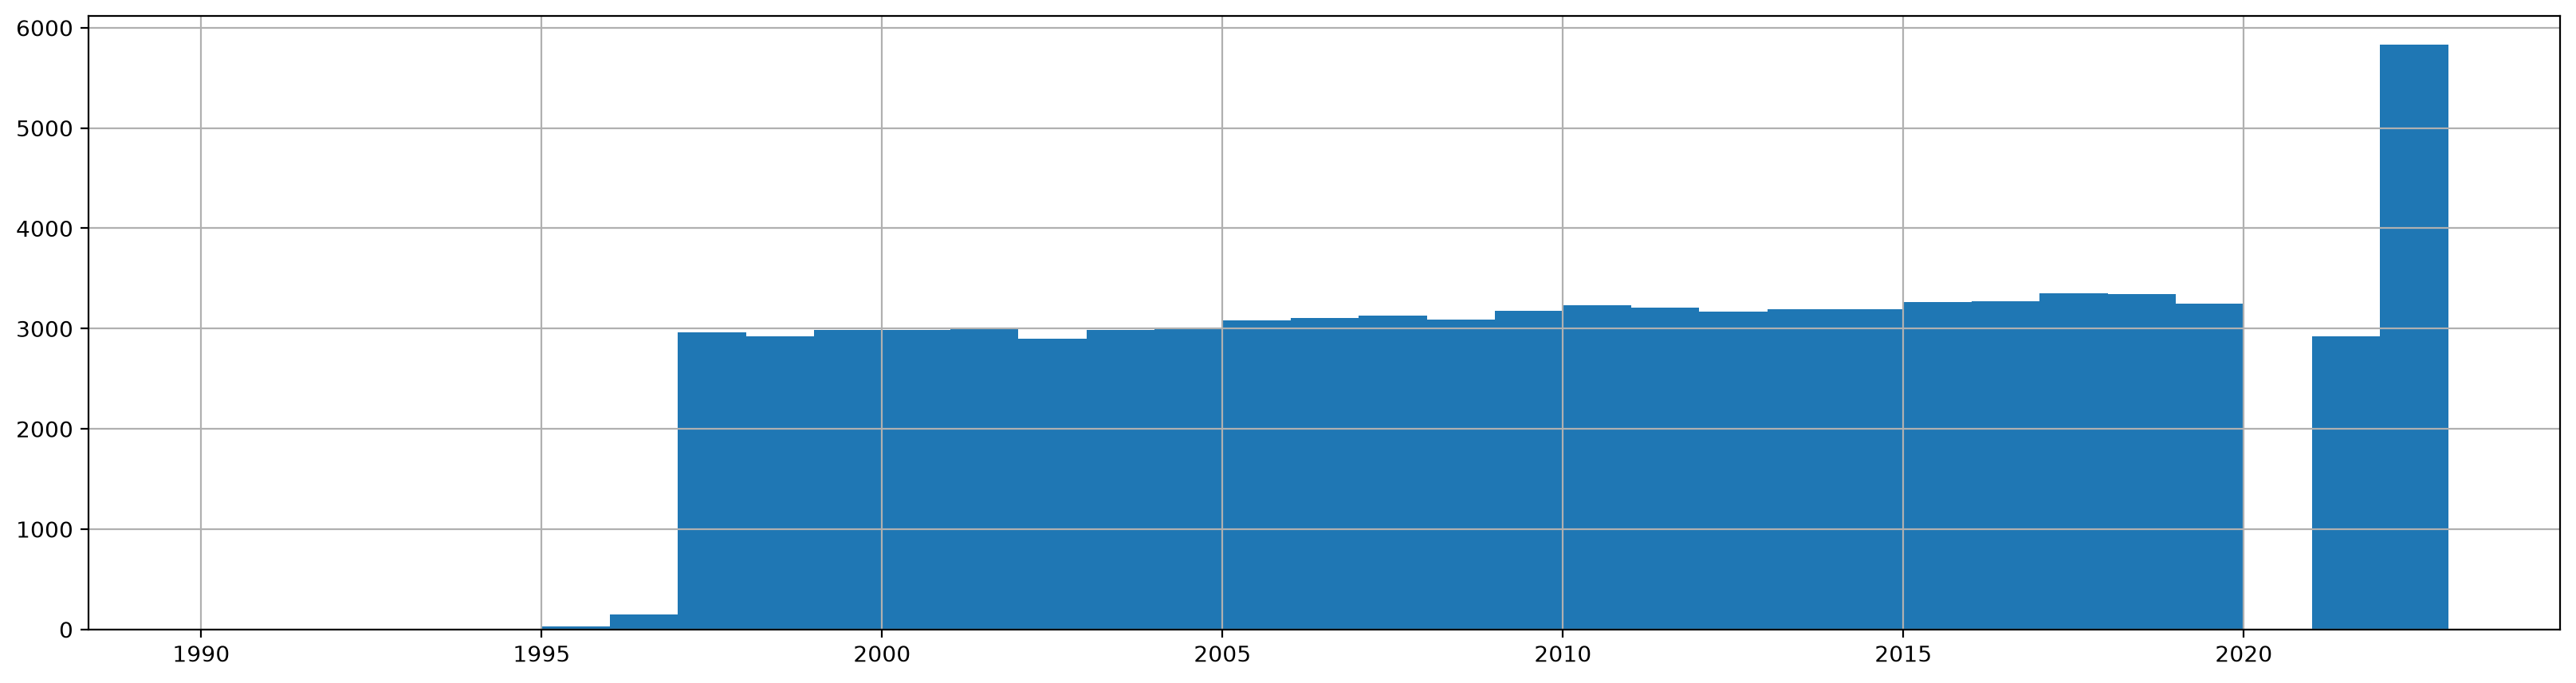

In [86]:
wide_w_names['Year'].hist(bins=range(1990, 2024), figsize=(20,5))

(array([24131., 12393.,  9171.,  8194.,  5523.,  4876.,  3185.,  5208.,
         1759.,  3868.,  2837.,  1902.,  2883.,  1764.,  1746.,  1786.,
         1404.,  1352.,   870.,  2923.,  1001.,   957.,  1044.,  1210.,
          825.,   896.,  1536.,   787.,   792.,  1073.,   717.,   935.,
          654.,   832.,   834.,   774.,   735.,   596.,   715.,  4075.]),
 array([0.02941176, 0.05367647, 0.07794118, 0.10220588, 0.12647059,
        0.15073529, 0.175     , 0.19926471, 0.22352941, 0.24779412,
        0.27205882, 0.29632353, 0.32058824, 0.34485294, 0.36911765,
        0.39338235, 0.41764706, 0.44191176, 0.46617647, 0.49044118,
        0.51470588, 0.53897059, 0.56323529, 0.5875    , 0.61176471,
        0.63602941, 0.66029412, 0.68455882, 0.70882353, 0.73308824,
        0.75735294, 0.78161765, 0.80588235, 0.83014706, 0.85441176,
        0.87867647, 0.90294118, 0.92720588, 0.95147059, 0.97573529,
        1.        ]),
 <BarContainer object of 40 artists>)

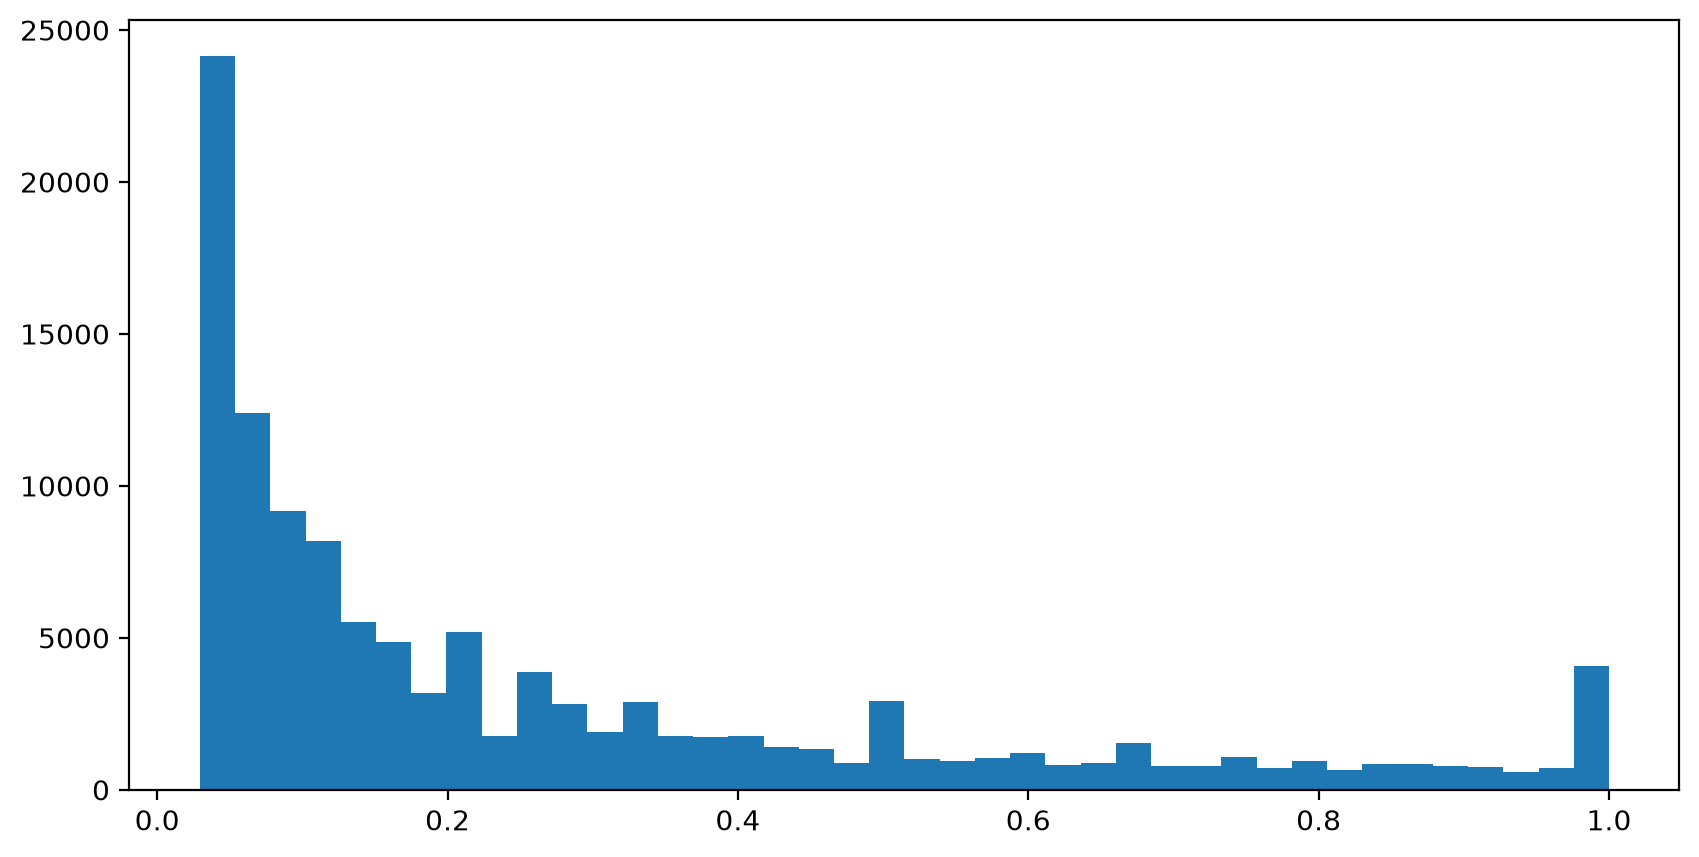

In [117]:
# frequency of occurrence (>0 entries) at a route across years:
detection_frequency = wide_w_names.drop(columns=['RouteDataID', 'Year']).groupby(['RouteID']).apply(lambda x: (x > 0).mean())
# flatten values and plot histogram, ignoring zeros
vals = detection_frequency.values.flatten()
vals = vals[vals > 0]
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(vals, bins=40)

In [ ]:
((wide_w_names>0).sum(0).sort_values(ascending=False)/len(wide_w_names)).round(2).head(100).tail(100-6)

/var/folders/_1/clc139q504qfy1s2zl7qf9h00000gr/T/ipykernel_94441/3216950054.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ((wide_w_names>0).sum(0).sort_values(ascending=False)/len(wide_w_names)).round(2).head(100).tail(100-6)


American Robin          0.52
Northern Cardinal       0.32
Mourning Dove           0.31
Chipping Sparrow        0.23
Song Sparrow            0.20
                        ... 
Scarlet Tanager         0.02
Brewer's Blackbird      0.01
Violet-green Swallow    0.01
Swamp Sparrow           0.01
Willow Flycatcher       0.01
Length: 94, dtype: float64